GitHub： https://github.com/lijing-Guo/Lijing-Guo/blob/main/ATUA%20Final/ATUA_Assignment_final_report.ipynb

# Agent-Based Modelling of Cycling Route Choice in Edinburgh

## 1. Introduction and research question

This project investigates how different route-choice assumptions change simulated cycling flows across Edinburgh. Cycling route choice is not determined only by distance. Previous studies show that cyclists may also respond to traffic volume, turns, slope, road type, perceived safety and cycling infrastructure (Broach, Dill and Gliebe, 2012; Hood, Sall and Charlton, 2011). This means that a purely shortest-path model may not fully represent how cyclists choose routes in real urban environments.

This project therefore uses Agent-Based Modelling (ABM) to compare three behavioural assumptions. ABM is suitable for this project because it represents individual agents moving through a spatial network and allows different behavioural rules to be tested (Crooks and Heppenstall, 2012). The cycling network is built from OpenStreetMap data using OSMnx, which provides a reproducible way to download and analyse street networks as graph structures (Boeing, 2017). In this model, cyclist agents are assigned origins and destinations on the Edinburgh cycling network, and their routes are calculated under different cost assumptions.

**Main research question:**
How do shortest-route preference, quiet/core path preference and low-speed/safety preference change the simulated spatial distribution of cycling flows in Edinburgh?

**Sub-questions:**

1. How does the shortest-route scenario distribute simulated cycling flows across the Edinburgh cycling network?
2. Does adding a quiet/core path preference shift simulated cycling flows towards cycling-friendly infrastructure?
3. Does adding a low-speed/safety preference produce a more concentrated or more distributed flow pattern?
4. To what extent do simulated high-flow corridors align with observed high-count cycling counter locations?

The objectives are to build an OpenStreetMap cycling network, simulate 500 cyclist agents under three route-cost rules, compare the outputs using edge-level flow statistics and difference maps, and conduct a rough validation using observed cycling counter data. The project does not aim to predict exact real-world cycling volumes. Instead, it uses ABM as an exploratory method to test how different assumptions about cyclist behaviour may reshape simulated movement patterns across the city.


In [1]:
!pip install osmnx geopandas networkx contextily shapely matplotlib

In [ ]:
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from pathlib import Path
from shapely.geometry import Point


def add_route_flow(G, route, flow_attr, weight_attr):
    """Add one unit of flow to each edge used by a route.

    For parallel edges between the same two nodes, the edge with the lowest
    relevant weight is updated. This matches how NetworkX chooses the shortest
    path in a MultiDiGraph.
    """
    for u, v in zip(route[:-1], route[1:]):
        edge_data = G.get_edge_data(u, v)
        if edge_data is not None:
            key = min(
                edge_data.keys(),
                key=lambda k: edge_data[k].get(weight_attr, edge_data[k].get("length", 1))
            )
            G[u][v][key][flow_attr] += 1


# 2. Data sources and preparation

The analysis combines observed cycling counter data with spatial network and infrastructure layers. The OpenStreetMap cycling network provides the main ABM movement environment and is also used for Scenario 1, where agents choose routes based only on shortest network distance. Adopted Core Paths and Quiet Routes are both used in Scenario 2 because they represent cycling-friendly or more comfortable route environments. These two layers are combined to create a broader preferred-route layer. Speed Limits are used separately in Scenario 3 to represent a low-speed/safety preference.

| Dataset | Format | Role in the project |
|---|---|---|
| Edinburgh daily cycling counts | CSV | Observed cycling volumes used for mapping and rough validation |
| OpenStreetMap cycling network | Network graph | ABM movement environment and Scenario 1 shortest-route baseline using edge length |
| Adopted Core Paths | GeoJSON | Cycling-friendly infrastructure layer used to construct Scenario 2 |
| Quiet Routes | GeoJSON | Quiet/cycling-friendly route layer used to construct Scenario 2 |
| Speed Limits | GeoJSON | Road speed layer used to construct Scenario 3 low-speed/safety preference |

The raw counter dataset contains pedestrian and cycling records. The workflow keeps cycling records only, converts start time into date variables, removes invalid or negative counts, and focuses on 2025. After cleaning, the 2025 cycling subset contains 21,094 records across 60 counter sites. Records are aggregated by site to calculate mean daily cycling count.

In [3]:
counts = pd.read_csv("/Users/Guolijing/Desktop/ATUA/ATUA_Final_ABM_Cycling_Edinburgh/data/edinburgh_daily_cycling_counts.csv.csv")

core_paths = gpd.read_file("/Users/Guolijing/Desktop/ATUA/ATUA_Final_ABM_Cycling_Edinburgh/data/Adopted_Core_Paths.geojson")
quiet_routes = gpd.read_file("/Users/Guolijing/Desktop/ATUA/ATUA_Final_ABM_Cycling_Edinburgh/data/Quiet_Routes.geojson")
speed_limits = gpd.read_file("/Users/Guolijing/Desktop/ATUA/ATUA_Final_ABM_Cycling_Edinburgh/data/Speed_Limits.geojson")

In [4]:
counts.head()

,provider,area,siteID,location,latitude,longitude,startTime,endTime,count,class,validCountsDetected,withinExpectedLimits,usmart_id
0,City of Edinburgh Council,Edinburgh,EDH0031,Dundee Street,55.94114,-3.21646,2025-03-02T00:00:00,2025-03-03T00:00:00,471,cycle,True,True,cc38232f99d3f6784799fad34863955d
1,City of Edinburgh Council,Edinburgh,EDH0026,Stenhouse Drive,55.93332,-3.26913,2025-03-02T00:00:00,2025-03-03T00:00:00,0,cycle,False,True,16da7c8bbdf64c6c1967bd5bf0d4bef2
2,City of Edinburgh Council,Edinburgh,EDH0052,A8 Wester Coates,55.94579,-3.22914,2025-03-02T00:00:00,2025-03-03T00:00:00,0,cycle,False,True,e7409419e6426eaf45d87dc000f1de45
3,City of Edinburgh Council,Edinburgh,EDH0201,Little France ELGT,55.92741,-3.13835,2025-03-02T00:00:00,2025-03-03T00:00:00,0,cycle,False,True,d01edee639a54e8423b715819c7803bb
4,City of Edinburgh Council,Edinburgh,EDH0208,Shawfair,55.90955,-3.09895,2025-03-02T00:00:00,2025-03-03T00:00:00,47,cycle,True,True,e46ddbe2edf72fcc06079a16e7a3414b


In [5]:
counts.columns

Index(['provider', 'area', 'siteID', 'location', 'latitude', 'longitude',
       'startTime', 'endTime', 'count', 'class', 'validCountsDetected',
       'withinExpectedLimits', 'usmart_id'],
      dtype='str')

In [6]:
counts.info()

<class 'pandas.DataFrame'>
RangeIndex: 454618 entries, 0 to 454617
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   provider              454618 non-null  str    
 1   area                  454618 non-null  str    
 2   siteID                454618 non-null  str    
 3   location              454618 non-null  str    
 4   latitude              454618 non-null  float64
 5   longitude             454618 non-null  float64
 6   startTime             454618 non-null  str    
 7   endTime               454618 non-null  str    
 8   count                 454618 non-null  int64  
 9   class                 454618 non-null  str    
 10  validCountsDetected   405011 non-null  object 
 11  withinExpectedLimits  405011 non-null  object 
 12  usmart_id             454618 non-null  str    
dtypes: float64(2), int64(1), object(2), str(8)
memory usage: 105.9+ MB


In [7]:
counts["class"].value_counts()

class
cycle         227398
pedestrian    227220
Name: count, dtype: int64

In [8]:
cycle_counts = counts[counts["class"] == "cycle"].copy()

cycle_counts.shape

(227398, 13)

In [9]:
cycle_counts.head()

,provider,area,siteID,location,latitude,longitude,startTime,endTime,count,class,validCountsDetected,withinExpectedLimits,usmart_id
0,City of Edinburgh Council,Edinburgh,EDH0031,Dundee Street,55.94114,-3.21646,2025-03-02T00:00:00,2025-03-03T00:00:00,471,cycle,True,True,cc38232f99d3f6784799fad34863955d
1,City of Edinburgh Council,Edinburgh,EDH0026,Stenhouse Drive,55.93332,-3.26913,2025-03-02T00:00:00,2025-03-03T00:00:00,0,cycle,False,True,16da7c8bbdf64c6c1967bd5bf0d4bef2
2,City of Edinburgh Council,Edinburgh,EDH0052,A8 Wester Coates,55.94579,-3.22914,2025-03-02T00:00:00,2025-03-03T00:00:00,0,cycle,False,True,e7409419e6426eaf45d87dc000f1de45
3,City of Edinburgh Council,Edinburgh,EDH0201,Little France ELGT,55.92741,-3.13835,2025-03-02T00:00:00,2025-03-03T00:00:00,0,cycle,False,True,d01edee639a54e8423b715819c7803bb
4,City of Edinburgh Council,Edinburgh,EDH0208,Shawfair,55.90955,-3.09895,2025-03-02T00:00:00,2025-03-03T00:00:00,47,cycle,True,True,e46ddbe2edf72fcc06079a16e7a3414b


In [10]:
cycle_counts["date"] = pd.to_datetime(cycle_counts["startTime"])
cycle_counts["year"] = cycle_counts["date"].dt.year
cycle_counts["month"] = cycle_counts["date"].dt.month
cycle_counts["day_of_week"] = cycle_counts["date"].dt.day_name()
cycle_counts["is_weekend"] = cycle_counts["date"].dt.dayofweek >= 5

In [11]:
cycle_counts_clean = cycle_counts[
    (cycle_counts["withinExpectedLimits"] == True) &
    (cycle_counts["count"] >= 0)
].copy()

cycle_counts_clean.shape

(187976, 18)

In [12]:
cycle_2025 = cycle_counts_clean[cycle_counts_clean["year"] == 2025].copy()

cycle_2025.shape

(21094, 18)

In [13]:
cycle_2025["siteID"].nunique()

60

In [14]:
counter_locations = cycle_2025.groupby(["siteID", "location"], as_index=False).agg({
    "latitude": "first",
    "longitude": "first",
    "count": "mean"
})

counter_locations = counter_locations.rename(columns={"count": "mean_daily_cycle_count"})

counter_locations.head()

,siteID,location,latitude,longitude,mean_daily_cycle_count
0,EDH0007,Wester Coates,55.94752,-3.23324,0.000000
1,EDH0020,Portobello Promenade,55.95455,-3.10951,198.818697
2,EDH0021,Morrison Street,55.94586,-3.20889,14.458924
3,EDH0022,"North Meadow Walk, Main Path",55.94154,-3.18507,1060.096317
4,EDH0023,"North Meadow Walk, Link",55.94138,-3.18493,249.597734


In [15]:
counter_gdf = gpd.GeoDataFrame(
    counter_locations,
    geometry=gpd.points_from_xy(counter_locations["longitude"], counter_locations["latitude"]),
    crs="EPSG:4326"
)

counter_gdf.head()

,siteID,location,latitude,longitude,mean_daily_cycle_count,geometry
0,EDH0007,Wester Coates,55.94752,-3.23324,0.000000,POINT (-3.23324 55.94752)
1,EDH0020,Portobello Promenade,55.95455,-3.10951,198.818697,POINT (-3.10951 55.95455)
2,EDH0021,Morrison Street,55.94586,-3.20889,14.458924,POINT (-3.20889 55.94586)
3,EDH0022,"North Meadow Walk, Main Path",55.94154,-3.18507,1060.096317,POINT (-3.18507 55.94154)
4,EDH0023,"North Meadow Walk, Link",55.94138,-3.18493,249.597734,POINT (-3.18493 55.94138)


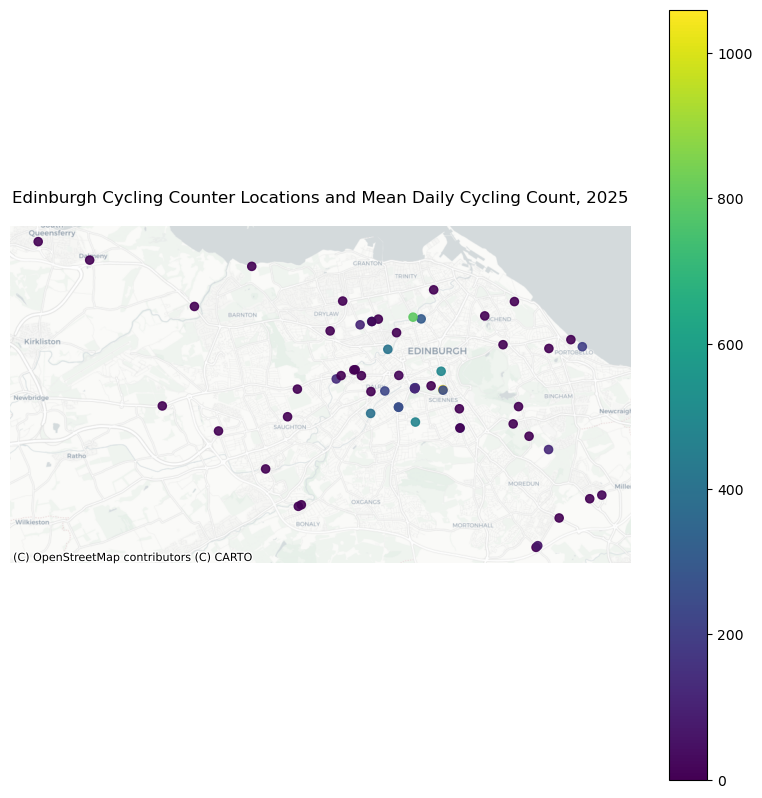

In [16]:
import contextily as ctx
import matplotlib.pyplot as plt

# Convert counter points to Web Mercator for basemap
counter_gdf_3857 = counter_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot counter points
counter_gdf_3857.plot(
    ax=ax,
    markersize=35,
    column="mean_daily_cycle_count",
    legend=True,
    alpha=0.9
)

# Add grey basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("Edinburgh Cycling Counter Locations and Mean Daily Cycling Count, 2025")
ax.set_axis_off()

plt.show()

In [17]:
core_paths.head()

,OBJECTID,CP_Number,Name,sub_name,ON_OFF_ROA,Change,PATH_TYPE,Shapelen,geometry
0,1,CEC3,Blackford Hill to The Meadows,,On Road,18/01/07,CP,777.293872,"LINESTRING (-3.19359 55.92864, -3.19143 55.928..."
1,2,CEC3,Blackford Hill to The Meadows,,On Road,20/12/06,CP,313.541475,"LINESTRING (-3.19359 55.92864, -3.19359 55.928..."
2,3,CEC10,Newbridge to Queensferry and Kirkliston,,Off Road,,CP,339.993380,"LINESTRING (-3.40145 55.94282, -3.4015 55.9423..."
3,4,CEC1,Burdiehouse Burn Valley Park,Craigmillar Castle Park,Off Road,21/5/07 uncertain route,CP,232.457308,"LINESTRING (-3.14763 55.9301, -3.1464 55.92927..."
4,5,CEC6,Firth of Forth,,Off Road,,CP,565.812481,"LINESTRING (-3.13659 55.96808, -3.13825 55.968..."


In [18]:
quiet_routes.head()

,OBJECTID,Route_No,Id,Name,Descript,Link_Ref,R_Status,R_Adopted,R_Type,R_Category,...,Length_m,Status,Timescale,QR_Standar,URL,Display,Upgrade,InfoLink,Shape__Length,geometry
0,1,13,1,NEPN,Goldenacre Path,144_147,Off-road,Prospectively Adopted,Unclassified Single,Remote Footway / Cycleway,...,875,Upgraded,Short,N,,,,https://www.edinburgh.gov.uk/cycling-walking/e...,874.820404,"LINESTRING (-3.1993 55.96657, -3.1995 55.96701..."
1,2,6,2,Argyle Place to Mayfield Road,Lauder Road,127_192,On-road,Adopted,"LA Non Principal, C Road Single",District / Local Distributor,...,586,Constructed,,,,,,https://www.edinburgh.gov.uk/cycling-walking/e...,586.337759,"LINESTRING (-3.18237 55.93143, -3.18319 55.932..."
2,3,13,20,NEPN,Trinity Path,142_144,Off-road,Adopted,Unclassified Single,Remote Footway / Cycleway,...,682,Upgraded,Short,N,,,,https://www.edinburgh.gov.uk/cycling-walking/e...,682.099994,"LINESTRING (-3.20238 55.97424, -3.20244 55.974..."
3,4,13,21,Lower Granton Road link path,McKelvie Parade,142_144,Off-road,Adopted,Unclassified Single,Remote Footway / Cycleway,...,588,Proposed Upgrade,Short,N,,,,https://www.edinburgh.gov.uk/cycling-walking/e...,587.743250,"LINESTRING (-3.2062 55.97979, -3.20639 55.9798..."
4,5,20,54,,,137_138,Off-road,Adopted,Unclassified Single,Remote Footway / Cycleway,...,326,Constructed,,,,,,https://www.edinburgh.gov.uk/cycling-walking/e...,325.682646,"LINESTRING (-3.2166 55.96233, -3.21579 55.9624..."


In [19]:
speed_limits.head()

,OBJECTID,FEATID,LAYER,Shape__Length,geometry
0,1,1,20mph,919.837993,"LINESTRING Z (-3.18986 55.93091 0, -3.18957 55..."
1,2,2,20mph,142.278944,"LINESTRING Z (-3.20494 55.93321 0, -3.20493 55..."
2,3,3,20mph,374.398115,"LINESTRING Z (-3.18287 55.95919 0, -3.18266 55..."
3,4,4,20mph,154.094941,"LINESTRING Z (-3.25828 55.96635 0, -3.2583 55...."
4,5,5,20mph,191.081298,"LINESTRING Z (-3.32196 55.90709 0, -3.32226 55..."


In [20]:
print(core_paths.crs)
print(quiet_routes.crs)
print(speed_limits.crs)
print(counter_gdf.crs)

EPSG:4326
EPSG:4326
EPSG:4326
EPSG:4326


In [21]:
counter_gdf_27700 = counter_gdf.to_crs(epsg=27700)
core_paths_27700 = core_paths.to_crs(epsg=27700)
quiet_routes_27700 = quiet_routes.to_crs(epsg=27700)
speed_limits_27700 = speed_limits.to_crs(epsg=27700)

## 2.1 Filter and clean the cycling counter data

This step prepares the cycling counter data for mapping and validation. The original dataset contains both pedestrian and cycling records, so only records labelled as `cycle` are retained. Invalid observations are removed by keeping only records where `withinExpectedLimits` is `True`, and negative count values are excluded. After cleaning, the analysis focuses on 2025 cycling records only. This ensures that the validation is based on recent and reliable cycling observations.

In [22]:
(counter_gdf["mean_daily_cycle_count"] == 0).sum()

np.int64(33)

In [23]:
counter_gdf[counter_gdf["mean_daily_cycle_count"] == 0]

,siteID,location,latitude,longitude,mean_daily_cycle_count,geometry
0,EDH0007,Wester Coates,55.94752,-3.23324,0.0,POINT (-3.23324 55.94752)
6,EDH0025,Straiton Path,55.89368,-3.13457,0.0,POINT (-3.13457 55.89368)
7,EDH0026,Stenhouse Drive,55.93332,-3.26913,0.0,POINT (-3.26913 55.93332)
10,EDH0029,A8 Corstorphine Road,55.94579,-3.24015,0.0,POINT (-3.24015 55.94579)
11,EDH0030,Dalry Road,55.94096,-3.22398,0.0,POINT (-3.22398 55.94096)
14,EDH0033,London Road,55.95517,-3.15246,0.0,POINT (-3.15246 55.95517)
17,EDH0036,Raeburn Place,55.95881,-3.21011,0.0,POINT (-3.21011 55.95881)
22,EDH0041,Mayfield Road Northbound,55.92990,-3.17578,0.0,POINT (-3.17578 55.9299)
27,EDH0046,Fishwives Causeway,55.95403,-3.12761,0.0,POINT (-3.12761 55.95403)
28,EDH0047,Inverleith Park,55.96292,-3.21997,0.0,POINT (-3.21997 55.96292)


In [24]:
counter_gdf = counter_gdf[counter_gdf["mean_daily_cycle_count"] > 0].copy()

## 2.2 Map observed cycling counter locations

The counter map shows the spatial distribution of 2025 cycling counter sites and their mean recorded cycling counts. Darker purple points indicate lower observed cycling activity, while green and yellow points indicate higher activity. Higher-count counters are mainly located around central and inner-city corridors, while several sites record very low values. Therefore, the counter data is useful for rough validation, but it should not be treated as a complete representation of all cycling movements in Edinburgh.

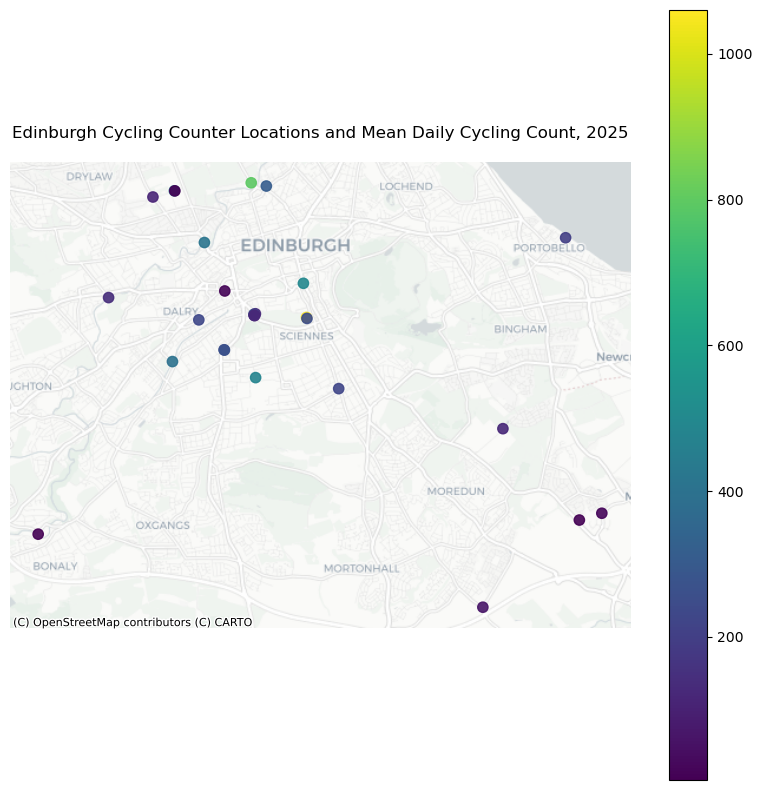

In [25]:
# Convert to Web Mercator for basemap
counter_gdf_3857 = counter_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot cycling counters
counter_gdf_3857.plot(
    ax=ax,
    column="mean_daily_cycle_count",
    markersize=55,
    legend=True,
    alpha=0.9
)

# Add grey basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("Edinburgh Cycling Counter Locations and Mean Daily Cycling Count, 2025")
ax.set_axis_off()

plt.show()

## 2.3 Inspect supporting spatial layers

The supporting spatial layers define the route-choice assumptions used in the ABM. Adopted Core Paths and Quiet Routes support Scenario 2, while Speed Limits support Scenario 3.

In [26]:
core_paths.head()

,OBJECTID,CP_Number,Name,sub_name,ON_OFF_ROA,Change,PATH_TYPE,Shapelen,geometry
0,1,CEC3,Blackford Hill to The Meadows,,On Road,18/01/07,CP,777.293872,"LINESTRING (-3.19359 55.92864, -3.19143 55.928..."
1,2,CEC3,Blackford Hill to The Meadows,,On Road,20/12/06,CP,313.541475,"LINESTRING (-3.19359 55.92864, -3.19359 55.928..."
2,3,CEC10,Newbridge to Queensferry and Kirkliston,,Off Road,,CP,339.993380,"LINESTRING (-3.40145 55.94282, -3.4015 55.9423..."
3,4,CEC1,Burdiehouse Burn Valley Park,Craigmillar Castle Park,Off Road,21/5/07 uncertain route,CP,232.457308,"LINESTRING (-3.14763 55.9301, -3.1464 55.92927..."
4,5,CEC6,Firth of Forth,,Off Road,,CP,565.812481,"LINESTRING (-3.13659 55.96808, -3.13825 55.968..."


In [27]:
quiet_routes.head()

,OBJECTID,Route_No,Id,Name,Descript,Link_Ref,R_Status,R_Adopted,R_Type,R_Category,...,Length_m,Status,Timescale,QR_Standar,URL,Display,Upgrade,InfoLink,Shape__Length,geometry
0,1,13,1,NEPN,Goldenacre Path,144_147,Off-road,Prospectively Adopted,Unclassified Single,Remote Footway / Cycleway,...,875,Upgraded,Short,N,,,,https://www.edinburgh.gov.uk/cycling-walking/e...,874.820404,"LINESTRING (-3.1993 55.96657, -3.1995 55.96701..."
1,2,6,2,Argyle Place to Mayfield Road,Lauder Road,127_192,On-road,Adopted,"LA Non Principal, C Road Single",District / Local Distributor,...,586,Constructed,,,,,,https://www.edinburgh.gov.uk/cycling-walking/e...,586.337759,"LINESTRING (-3.18237 55.93143, -3.18319 55.932..."
2,3,13,20,NEPN,Trinity Path,142_144,Off-road,Adopted,Unclassified Single,Remote Footway / Cycleway,...,682,Upgraded,Short,N,,,,https://www.edinburgh.gov.uk/cycling-walking/e...,682.099994,"LINESTRING (-3.20238 55.97424, -3.20244 55.974..."
3,4,13,21,Lower Granton Road link path,McKelvie Parade,142_144,Off-road,Adopted,Unclassified Single,Remote Footway / Cycleway,...,588,Proposed Upgrade,Short,N,,,,https://www.edinburgh.gov.uk/cycling-walking/e...,587.743250,"LINESTRING (-3.2062 55.97979, -3.20639 55.9798..."
4,5,20,54,,,137_138,Off-road,Adopted,Unclassified Single,Remote Footway / Cycleway,...,326,Constructed,,,,,,https://www.edinburgh.gov.uk/cycling-walking/e...,325.682646,"LINESTRING (-3.2166 55.96233, -3.21579 55.9624..."


In [28]:
speed_limits.head()

,OBJECTID,FEATID,LAYER,Shape__Length,geometry
0,1,1,20mph,919.837993,"LINESTRING Z (-3.18986 55.93091 0, -3.18957 55..."
1,2,2,20mph,142.278944,"LINESTRING Z (-3.20494 55.93321 0, -3.20493 55..."
2,3,3,20mph,374.398115,"LINESTRING Z (-3.18287 55.95919 0, -3.18266 55..."
3,4,4,20mph,154.094941,"LINESTRING Z (-3.25828 55.96635 0, -3.2583 55...."
4,5,5,20mph,191.081298,"LINESTRING Z (-3.32196 55.90709 0, -3.32226 55..."


In [29]:
print("Counters:", counter_gdf.crs)
print("Core paths:", core_paths.crs)
print("Quiet routes:", quiet_routes.crs)
print("Speed limits:", speed_limits.crs)

Counters: EPSG:4326
Core paths: EPSG:4326
Quiet routes: EPSG:4326
Speed limits: EPSG:4326


## 2.4 Project spatial layers for distance-based analysis

The spatial layers are projected to British National Grid (EPSG:27700) for distance-based operations such as buffering and spatial intersection. Web Mercator (EPSG:3857) is used only for map visualisation with basemaps.

In [30]:
counter_gdf_27700 = counter_gdf.to_crs(epsg=27700)
core_paths_27700 = core_paths.to_crs(epsg=27700)
quiet_routes_27700 = quiet_routes.to_crs(epsg=27700)
speed_limits_27700 = speed_limits.to_crs(epsg=27700)

In [31]:
print(counter_gdf_27700.crs)
print(core_paths_27700.crs)
print(quiet_routes_27700.crs)
print(speed_limits_27700.crs)

EPSG:27700
EPSG:27700
EPSG:27700
EPSG:27700


## 2.5 Overlay cycling counters with core paths and quiet routes

This map overlays observed cycling counter locations with Adopted Core Paths and Quiet Routes. It provides an initial visual check of whether monitored cycling activity is located near cycling-friendly infrastructure. Some counters appear close to these route layers, especially around central Edinburgh and connected corridor areas. This supports the later design of Scenario 2, where routes near core paths and quiet routes are treated as preferred cycling corridors. However, not all counters are located close to these layers, which suggests that observed cycling activity may also occur on ordinary streets outside the preferred-route network.


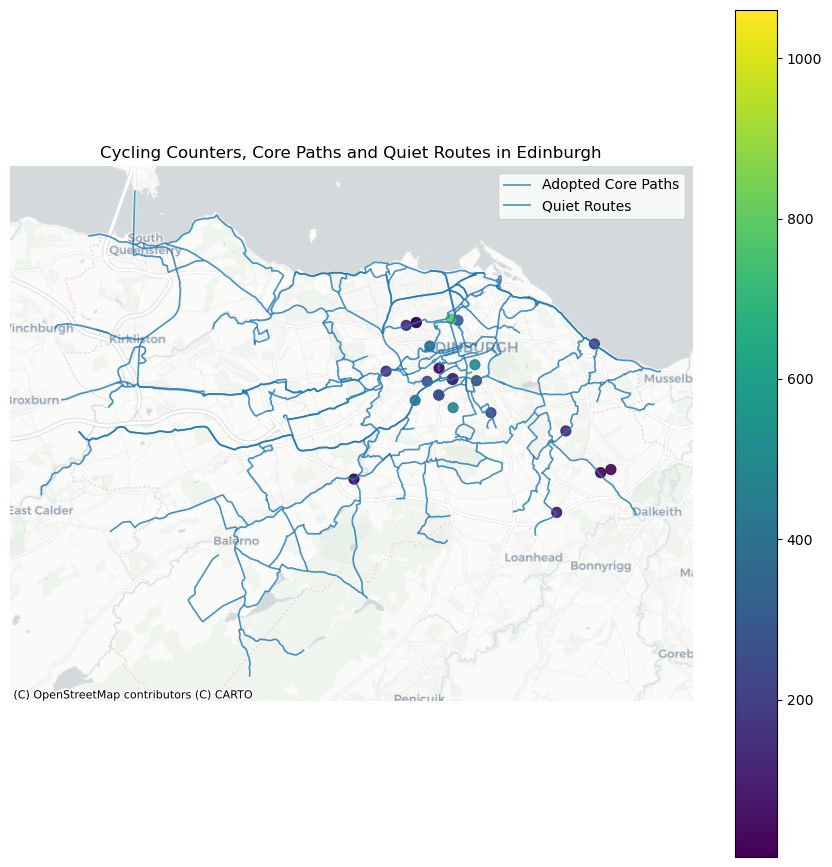

In [32]:
# Convert all layers to Web Mercator
counter_gdf_3857 = counter_gdf.to_crs(epsg=3857)
core_paths_3857 = core_paths.to_crs(epsg=3857)
quiet_routes_3857 = quiet_routes.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(11, 11))

# Add route layers first
core_paths_3857.plot(
    ax=ax,
    linewidth=1.2,
    alpha=0.8,
    label="Adopted Core Paths"
)

quiet_routes_3857.plot(
    ax=ax,
    linewidth=1.2,
    alpha=0.8,
    label="Quiet Routes"
)

# Add counter points
counter_gdf_3857.plot(
    ax=ax,
    column="mean_daily_cycle_count",
    markersize=50,
    legend=True,
    alpha=0.9
)

# Add grey basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("Cycling Counters, Core Paths and Quiet Routes in Edinburgh")
ax.set_axis_off()
ax.legend()

plt.show()

# 3. ABM network environment and model design

The ABM environment is the OpenStreetMap cycling network for Edinburgh. Nodes represent intersections or junctions, and edges represent street or path segments. Each simulated cyclist has an origin and destination node. Agents are routed through the graph using shortest-path algorithms, but the edge cost changes by scenario.

The model is not intended to forecast exact cycling volumes. It is a controlled scenario experiment: the same 500 origin-destination pairs are used in all scenarios, so differences in flow are caused by route-choice rules rather than different simulated demand.

## 3.1 Download the Edinburgh cycling network


In [33]:
place = "Edinburgh, Scotland, United Kingdom"

G = ox.graph_from_place(
    place,
    network_type="bike",
    simplify=True
)

In [34]:
print("Number of nodes:", len(G.nodes))
print("Number of edges:", len(G.edges))

Number of nodes: 37280
Number of edges: 86660


## 3.2 Visualise the cycling network


The OSMnx cycling network is used as the ABM environment. Nodes represent intersections or network points, while edges represent cycling-accessible road or path segments. The network contains 37,280 nodes and 86,660 edges, allowing cyclist agents to move through connected routes under different cost assumptions.


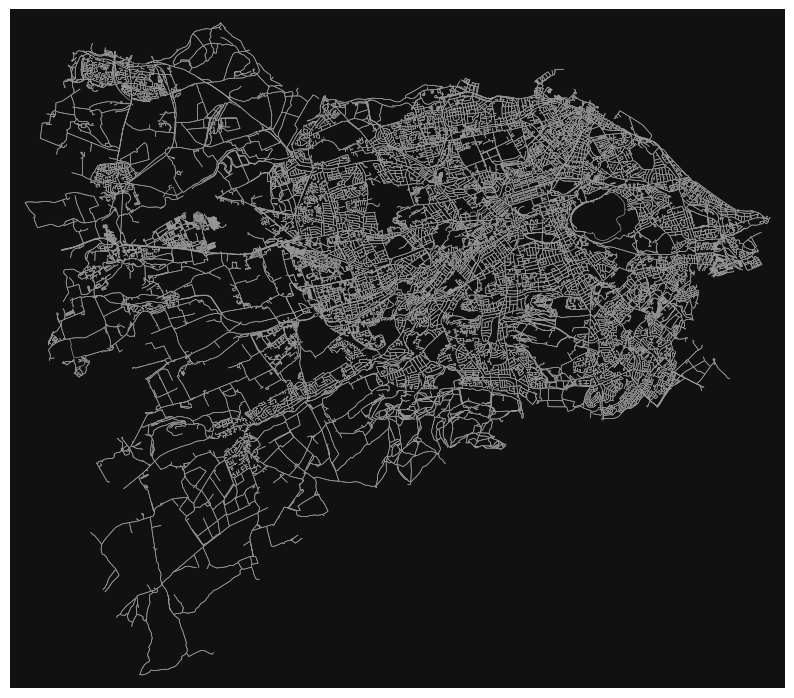

In [35]:
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_linewidth=0.5,
    figsize=(10, 10)
)

## 3.3 Convert the network to GeoDataFrames



The network was converted into GeoDataFrames so that nodes and edges could be analysed spatially. This step allows the graph structure to be linked with GIS operations, such as projection, mapping and spatial overlays with cycling infrastructure layers.


In [36]:
nodes, edges = ox.graph_to_gdfs(G)

nodes.head()

,y,x,street_count,highway,junction,railway,geometry
osmid,,,,,,,
363837,55.965136,-3.317721,3,NaN,NaN,NaN,POINT (-3.31772 55.96514)
363855,55.978531,-3.344264,1,NaN,NaN,NaN,POINT (-3.34426 55.97853)
363900,55.979399,-3.396278,1,NaN,NaN,NaN,POINT (-3.39628 55.9794)
363913,55.981478,-3.400987,3,motorway_junction,NaN,NaN,POINT (-3.40099 55.98148)
363917,55.988829,-3.404788,1,NaN,NaN,NaN,POINT (-3.40479 55.98883)


In [37]:
edges.head()

osmid  highway lanes maxspeed  \
u      v           key                                       
363837 37922740    0      23681871  primary     4   40 mph   
       9688802180  0      23681871  primary     4   40 mph   
       31100731    0    1054291056  service   NaN      NaN   
363900 363913      0     379435998  service     3   50 mph   
363913 10752101882 0       4042540  service     2   50 mph   

                                                                     name  \
u      v           key                                                      
363837 37922740    0                                     Queensferry Road   
       9688802180  0                                     Queensferry Road   
       31100731    0                                                  NaN   
363900 363913      0    Queensferry Crossing Diversion Route (northbound)   
363913 10752101882 0                                                  NaN   

                        ref  oneway reversed      length access  \
u      v           key                                            
363837 37922740    0    A90   False    False   76.367096    NaN   
       9688802180  0    A90   False     True   46.456581    NaN   
       31100731    0    NaN    True    False   15.041433    NaN   
363900 363913      0    NaN    True    False  376.902055     no   
363913 10752101882 0    NaN    True    False  321.676550     no   

                                                                 geometry  \
u      v           key                                                      
363837 37922740    0    LINESTRING (-3.31772 55.96514, -3.31845 55.96569)   
       9688802180  0     LINESTRING (-3.31772 55.96514, -3.31728 55.9648)   
       31100731    0    LINESTRING (-3.31772 55.96514, -3.31753 55.96522)   
363900 363913      0    LINESTRING (-3.39628 55.9794, -3.39681 55.9795...   
363913 10752101882 0    LINESTRING (-3.40099 55.98148, -3.40164 55.981...   

                       junction bridge service tunnel width est_width area  
u      v           key                                                      
363837 37922740    0        NaN    NaN     NaN    NaN   NaN       NaN  NaN  
       9688802180  0        NaN    NaN     NaN    NaN   NaN       NaN  NaN  
       31100731    0        NaN    NaN     NaN    NaN   NaN       NaN  NaN  
363900 363913      0        NaN    NaN     NaN    NaN   NaN       NaN  NaN  
363913 10752101882 0        NaN    NaN     NaN    NaN   NaN       NaN  NaN

In [38]:
print(nodes.crs)
print(edges.crs)

epsg:4326
epsg:4326


## 3.4 Project the network and inspect edge attributes


The network edges were projected to EPSG:27700 so that spatial overlays and distance-based operations could be carried out in metres. Inspecting the edge attributes also confirms that the network contains a `length` variable, which is later used as the baseline travel cost in Scenario 1.

In [39]:
nodes_27700 = nodes.to_crs(epsg=27700)
edges_27700 = edges.to_crs(epsg=27700)

core_paths_27700 = core_paths.to_crs(epsg=27700)
quiet_routes_27700 = quiet_routes.to_crs(epsg=27700)
speed_limits_27700 = speed_limits.to_crs(epsg=27700)
counter_gdf_27700 = counter_gdf.to_crs(epsg=27700)

In [40]:
edges.columns

Index(['osmid', 'highway', 'lanes', 'maxspeed', 'name', 'ref', 'oneway',
       'reversed', 'length', 'access', 'geometry', 'junction', 'bridge',
       'service', 'tunnel', 'width', 'est_width', 'area'],
      dtype='str')

In [41]:
edges["length"].describe()

count    86660.000000
mean        66.292648
std         92.911889
min          0.433237
25%         18.780887
50%         40.379918
75%         77.615575
max       2465.689574
Name: length, dtype: float64

## 3.5 Create the baseline shortest-route cost


The baseline cost is created from edge length. In Scenario 1, this means agents select the route with the lowest total distance between their origin and destination. This creates a simple reference scenario for later comparison.

In [42]:
for u, v, k, data in G.edges(keys=True, data=True):
    data["cost_shortest"] = data.get("length", 1)

## 3.6 Check edge cost attributes


This step checks that the new cost attribute has been added correctly to the network edges. This is important because the later shortest-path routing depends on these edge-level cost values.

In [43]:
sample_edge = list(G.edges(keys=True, data=True))[0]
sample_edge

(363837,
 37922740,
 0,
 {'osmid': 23681871,
  'highway': 'primary',
  'lanes': '4',
  'maxspeed': '40 mph',
  'name': 'Queensferry Road',
  'ref': 'A90',
  'oneway': False,
  'reversed': False,
  'length': np.float64(76.36709594487476),
  'cost_shortest': np.float64(76.36709594487476)})

## 3.7 Map the cycling network and observed counter locations


In [44]:
edges_3857 = edges.to_crs(epsg=3857)
counter_gdf_3857 = counter_gdf.to_crs(epsg=3857)

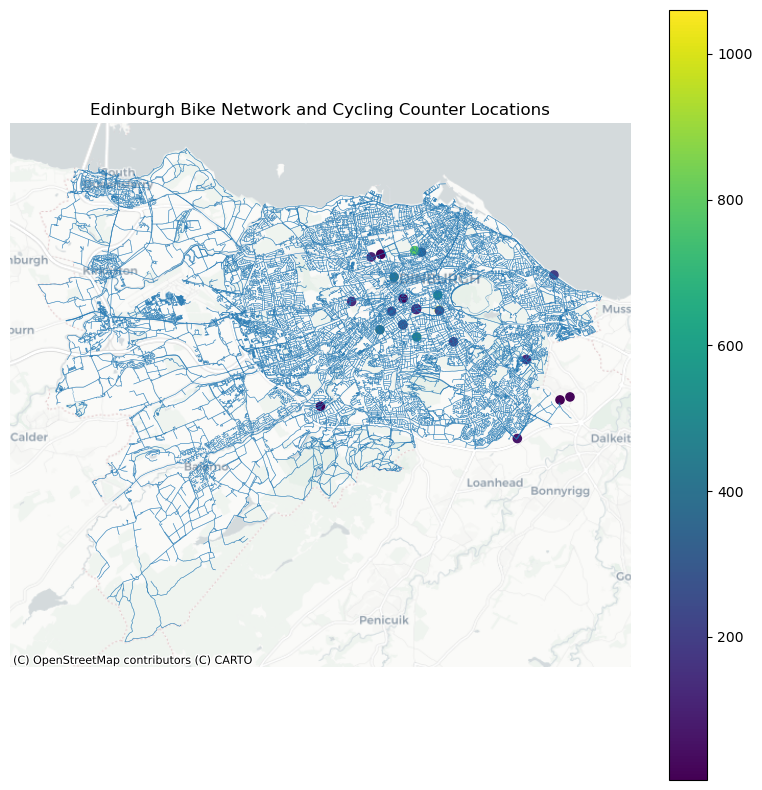

In [45]:
import contextily as ctx

fig, ax = plt.subplots(figsize=(10, 10))

edges_3857.plot(
    ax=ax,
    linewidth=0.4,
    alpha=0.6
)

counter_gdf_3857.plot(
    ax=ax,
    column="mean_daily_cycle_count",
    markersize=35,
    legend=True
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("Edinburgh Bike Network and Cycling Counter Locations")
ax.set_axis_off()
plt.show()

The map shows the OSMnx cycling-accessible network used as the ABM environment, with observed cycling counters overlaid as reference points. The grey lines represent road and path segments where simulated cyclist agents can travel, while the counter points show where real cycling observations are available. The map demonstrates that the network covers the wider Edinburgh urban area, providing enough spatial detail for route simulation. It also shows that cycling counters are only located at selected points rather than across the whole network. Therefore, the network is suitable for citywide ABM simulation, while the counters are mainly used later for rough validation.


# 4. Scenario 1: Shortest-route ABM simulation

Scenario 1 provides the baseline ABM simulation. In this scenario, cyclist agents are assumed to choose the shortest available route between their origin and destination using edge length as the only travel cost. This does not fully represent real cyclist behaviour, but it creates a clear reference case. The later scenarios can then be compared against this baseline to identify how quiet/core path preference and low-speed/safety preference change the simulated cycling flow pattern.


## 4.1 Create a list of network nodes


In [46]:
nodes_list = list(G.nodes)

len(nodes_list)

37280

## 4.2 Generate simulated cyclist agents


Simulated cyclist agents are created by randomly assigning origin and destination nodes from the cycling network. The same 500 origin-destination pairs are used in all scenarios, ensuring that differences in results come from route-choice assumptions rather than different trips.

In [47]:
np.random.seed(42)

n_agents = 500

origins = np.random.choice(nodes_list, size=n_agents, replace=True)
destinations = np.random.choice(nodes_list, size=n_agents, replace=True)

agents = pd.DataFrame({
    "agent_id": range(n_agents),
    "origin": origins,
    "destination": destinations
})

agents.head()

,agent_id,origin,destination
0,0,1018473580,4562325321
1,1,638508,1734225027
2,2,313044351,4548174989
3,3,38451415,13535506592
4,4,1362589825,695177


## 4.3 Remove agents with identical origins and destinations


In [48]:
agents = agents[agents["origin"] != agents["destination"]].copy()

agents.shape

(500, 3)

## 4.4 Initialise edge-level flow counts


Each network edge stores a simulated flow value. This value starts at zero and increases when an agent uses that edge during routing. This creates an edge-level flow output that can be mapped and compared across scenarios.

In [49]:
for u, v, k, data in G.edges(keys=True, data=True):
    data["flow_shortest"] = 0

## 4.5 Run the shortest-route simulation


In [50]:
successful_routes = 0
failed_routes = 0

for _, row in agents.iterrows():
    origin = row["origin"]
    destination = row["destination"]

    try:
        route = nx.shortest_path(
            G,
            source=origin,
            target=destination,
            weight="length"
        )

        successful_routes += 1
        add_route_flow(G, route, "flow_shortest", "length")

    except nx.NetworkXNoPath:
        failed_routes += 1

print("Successful routes:", successful_routes)
print("Failed routes:", failed_routes)


Successful routes: 500
Failed routes: 0


## 4.6 Convert simulation results to a GeoDataFrame


In [51]:
nodes_sim, edges_sim = ox.graph_to_gdfs(G)

edges_sim[["length", "flow_shortest"]].head()

length  flow_shortest
u      v           key                           
363837 37922740    0     76.367096             13
       9688802180  0     46.456581             18
       31100731    0     15.041433              0
363900 363913      0    376.902055              0
363913 10752101882 0    321.676550              0

In [52]:
edges_sim["flow_shortest"].describe()

count    86660.000000
mean         0.709566
std          2.466543
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         52.000000
Name: flow_shortest, dtype: float64

In [53]:
(edges_sim["flow_shortest"] > 0).sum()

np.int64(16731)

## 4.7 Map Scenario 1 simulated flow


In [54]:
edges_sim_3857 = edges_sim.to_crs(epsg=3857)

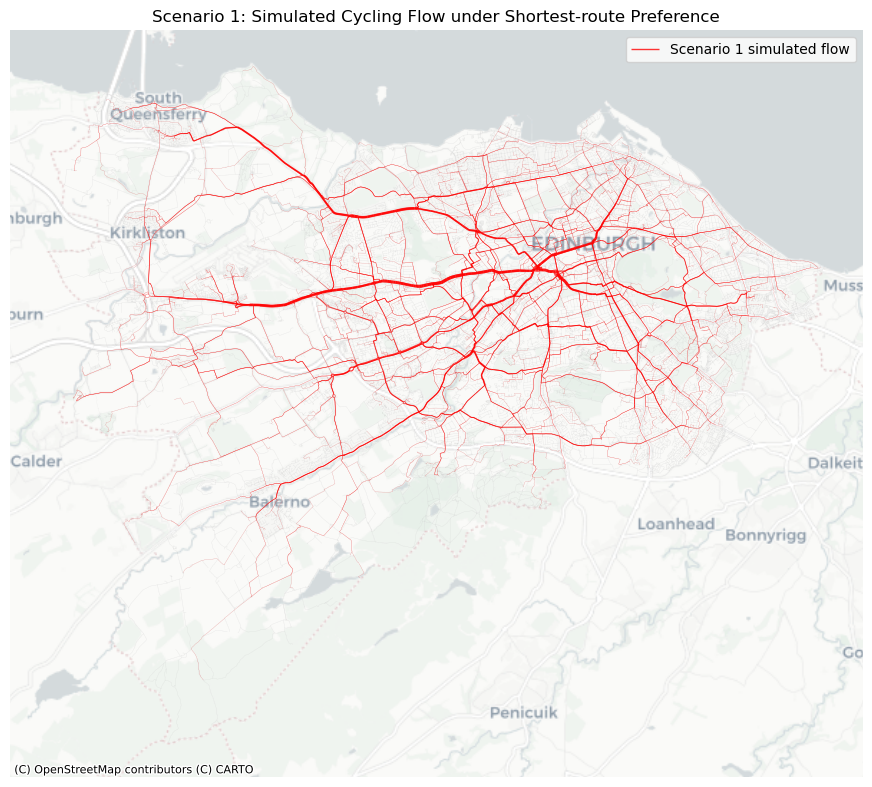

In [55]:
fig, ax = plt.subplots(figsize=(11, 11))

# Plot all bike network lightly
edges_sim_3857.plot(
    ax=ax,
    linewidth=0.2,
    color="lightgrey",
    alpha=0.3
)

# Plot used routes with line width based on flow
used_edges = edges_sim_3857[edges_sim_3857["flow_shortest"] > 0].copy()

used_edges.plot(
    ax=ax,
    linewidth=used_edges["flow_shortest"] / used_edges["flow_shortest"].max() * 4,
    color="red",
    alpha=0.8,
    label="Scenario 1 simulated flow"
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("Scenario 1: Simulated Cycling Flow under Shortest-route Preference")
ax.set_axis_off()
ax.legend()

plt.show()

In [ ]:
fig.savefig("/Users/Guolijing/Desktop/ATUA/ATUA_Final_ABM_Cycling_Edinburgh/figures/scenario_1_shortest_route_flow.png", dpi=300, bbox_inches="tight")


### Scenario 1 interpretation

The Scenario 1 results show that all 500 agents were successfully routed, with no failed trips. Simulated flow is distributed across 16,731 edges, with a maximum edge flow of 52 and a mean edge flow of approximately 0.710. The map shows several strong direct corridors, reflecting the logic of shortest-path routing. Since agents minimise distance only, flows tend to concentrate on efficient cross-city links. However, because origins and destinations are randomly distributed across the network, the simulated flow still spreads across many different edges rather than only one central route.


# 5. Scenario 2: Quiet/core path preference

Scenario 2 introduces a preference for cycling-friendly infrastructure. This is supported by route-choice studies showing that cyclists may accept longer routes to use more comfortable or protected environments (Broach, Dill and Gliebe, 2012; Hood, Sall and Charlton, 2011). A 30m buffer is created around adopted core paths and quiet routes. Edges within this buffer receive lower cost, while other edges receive higher cost.

## 5.1 Prepare network edges for spatial overlay


In [57]:
nodes_env, edges_env = ox.graph_to_gdfs(G)

edges_env.head()

osmid  highway lanes maxspeed  \
u      v           key                                       
363837 37922740    0      23681871  primary     4   40 mph   
       9688802180  0      23681871  primary     4   40 mph   
       31100731    0    1054291056  service   NaN      NaN   
363900 363913      0     379435998  service     3   50 mph   
363913 10752101882 0       4042540  service     2   50 mph   

                                                                     name  \
u      v           key                                                      
363837 37922740    0                                     Queensferry Road   
       9688802180  0                                     Queensferry Road   
       31100731    0                                                  NaN   
363900 363913      0    Queensferry Crossing Diversion Route (northbound)   
363913 10752101882 0                                                  NaN   

                        ref  oneway reversed      length  cost_shortest  \
u      v           key                                                    
363837 37922740    0    A90   False    False   76.367096      76.367096   
       9688802180  0    A90   False     True   46.456581      46.456581   
       31100731    0    NaN    True    False   15.041433      15.041433   
363900 363913      0    NaN    True    False  376.902055     376.902055   
363913 10752101882 0    NaN    True    False  321.676550     321.676550   

                        flow_shortest access  \
u      v           key                         
363837 37922740    0               13    NaN   
       9688802180  0               18    NaN   
       31100731    0                0    NaN   
363900 363913      0                0     no   
363913 10752101882 0                0     no   

                                                                 geometry  \
u      v           key                                                      
363837 37922740    0    LINESTRING (-3.31772 55.96514, -3.31845 55.96569)   
       9688802180  0     LINESTRING (-3.31772 55.96514, -3.31728 55.9648)   
       31100731    0    LINESTRING (-3.31772 55.96514, -3.31753 55.96522)   
363900 363913      0    LINESTRING (-3.39628 55.9794, -3.39681 55.9795...   
363913 10752101882 0    LINESTRING (-3.40099 55.98148, -3.40164 55.981...   

                       junction bridge service tunnel width est_width area  
u      v           key                                                      
363837 37922740    0        NaN    NaN     NaN    NaN   NaN       NaN  NaN  
       9688802180  0        NaN    NaN     NaN    NaN   NaN       NaN  NaN  
       31100731    0        NaN    NaN     NaN    NaN   NaN       NaN  NaN  
363900 363913      0        NaN    NaN     NaN    NaN   NaN       NaN  NaN  
363913 10752101882 0        NaN    NaN     NaN    NaN   NaN       NaN  NaN

In [58]:
edges_env_27700 = edges_env.to_crs(epsg=27700)
core_paths_27700 = core_paths.to_crs(epsg=27700)
quiet_routes_27700 = quiet_routes.to_crs(epsg=27700)

## 5.2 Create a buffer around quiet routes and core paths


In [59]:
preferred_routes_27700 = pd.concat(
    [core_paths_27700[["geometry"]], quiet_routes_27700[["geometry"]]],
    ignore_index=True
)

preferred_buffer = preferred_routes_27700.buffer(30).union_all()

## 5.3 Identify edges near preferred cycling routes


In [60]:
edges_env_27700["near_preferred_route"] = edges_env_27700.geometry.intersects(preferred_buffer)

edges_env_27700["near_preferred_route"].value_counts()

near_preferred_route
False    70444
True     16216
Name: count, dtype: int64

## 5.4 Create the quiet/core path preference cost


In [61]:
edges_env_27700["cost_preferred"] = np.where(
    edges_env_27700["near_preferred_route"],
    edges_env_27700["length"] * 0.6,
    edges_env_27700["length"] * 1.2
)

edges_env_27700[["length", "near_preferred_route", "cost_preferred"]].head()

length  near_preferred_route  cost_preferred
u      v           key                                                  
363837 37922740    0     76.367096                 False       91.640515
       9688802180  0     46.456581                 False       55.747898
       31100731    0     15.041433                  True        9.024860
363900 363913      0    376.902055                 False      452.282466
363913 10752101882 0    321.676550                 False      386.011860

## 5.5 Write Scenario 2 costs back to the graph


In [62]:
for (u, v, k), row in edges_env_27700.iterrows():
    G[u][v][k]["near_preferred_route"] = row["near_preferred_route"]
    G[u][v][k]["cost_preferred"] = row["cost_preferred"]
    G[u][v][k]["flow_preferred"] = 0

In [63]:
sample_edge = list(G.edges(keys=True, data=True))[0]
sample_edge

(363837,
 37922740,
 0,
 {'osmid': 23681871,
  'highway': 'primary',
  'lanes': '4',
  'maxspeed': '40 mph',
  'name': 'Queensferry Road',
  'ref': 'A90',
  'oneway': False,
  'reversed': False,
  'length': np.float64(76.36709594487476),
  'cost_shortest': np.float64(76.36709594487476),
  'flow_shortest': 13,
  'near_preferred_route': False,
  'cost_preferred': 91.64051513384972,
  'flow_preferred': 0})

## 5.6 Run Scenario 2 using the same agents


In [64]:
successful_routes_preferred = 0
failed_routes_preferred = 0

for _, row in agents.iterrows():
    origin = row["origin"]
    destination = row["destination"]

    try:
        route = nx.shortest_path(
            G,
            source=origin,
            target=destination,
            weight="cost_preferred"
        )

        successful_routes_preferred += 1
        add_route_flow(G, route, "flow_preferred", "cost_preferred")

    except nx.NetworkXNoPath:
        failed_routes_preferred += 1

print("Successful preferred routes:", successful_routes_preferred)
print("Failed preferred routes:", failed_routes_preferred)


Successful preferred routes: 500
Failed preferred routes: 0


## 5.7 Convert Scenario 2 results and inspect flow


In [65]:
nodes_sim2, edges_sim2 = ox.graph_to_gdfs(G)

edges_sim2[["length", "flow_shortest", "flow_preferred", "near_preferred_route"]].head()

length  flow_shortest  flow_preferred  \
u      v           key                                              
363837 37922740    0     76.367096             13               0   
       9688802180  0     46.456581             18               0   
       31100731    0     15.041433              0               3   
363900 363913      0    376.902055              0               0   
363913 10752101882 0    321.676550              0               0   

                        near_preferred_route  
u      v           key                        
363837 37922740    0                   False  
       9688802180  0                   False  
       31100731    0                    True  
363900 363913      0                   False  
363913 10752101882 0                   False

In [66]:
edges_sim2["flow_preferred"].describe()

count    86660.000000
mean         0.620621
std          2.959576
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         62.000000
Name: flow_preferred, dtype: float64

In [67]:
(edges_sim2["flow_preferred"] > 0).sum()

np.int64(13129)

## 5.8 Map Scenario 2 simulated flow


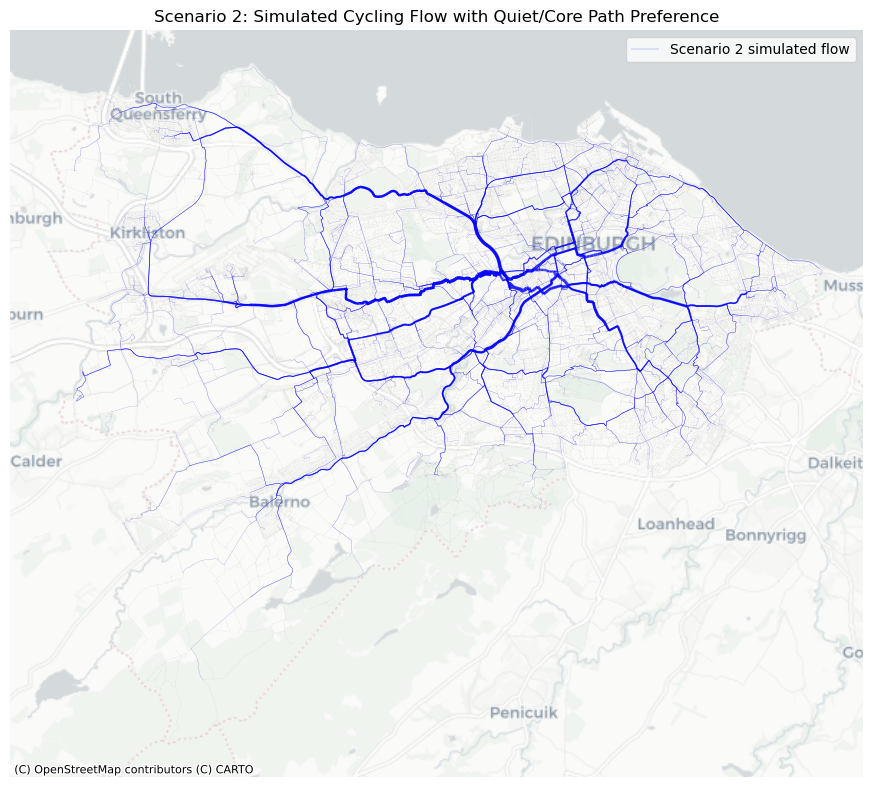

In [68]:
edges_sim2_3857 = edges_sim2.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(11, 11))

# Plot all bike network lightly
edges_sim2_3857.plot(
    ax=ax,
    linewidth=0.2,
    color="lightgrey",
    alpha=0.3
)

# Plot used routes with line width based on flow
used_edges_preferred = edges_sim2_3857[
    edges_sim2_3857["flow_preferred"] > 0
].copy()

used_edges_preferred.plot(
    ax=ax,
    linewidth=used_edges_preferred["flow_preferred"] / used_edges_preferred["flow_preferred"].max() * 4,
    color="blue",
    alpha=0.8,
    label="Scenario 2 simulated flow"
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("Scenario 2: Simulated Cycling Flow with Quiet/Core Path Preference")
ax.set_axis_off()
ax.legend()

plt.show()

In [ ]:
fig.savefig("/Users/Guolijing/Desktop/ATUA/ATUA_Final_ABM_Cycling_Edinburgh/figures/scenario_2_preferred_route_flow.png", dpi=300, bbox_inches="tight")


### Scenario 2 interpretation

The overlay identifies 16,216 edges near preferred routes and 70,444 outside them. Scenario 2 successfully routes all 500 agents. It uses fewer edges than Scenario 1, 13,129 compared with 16,731, but its maximum edge flow increases to 62. This means the quiet/core path rule concentrates simulated activity onto a smaller set of preferred corridors.

The map supports this result. Blue lines show simulated flow, with thicker lines representing higher agent counts. Compared with Scenario 1, the strongest flows are more focused, showing that infrastructure preference changes the geography of simulated movement.

# 6. Scenario 3: Low-speed / safety preference

Scenario 3 introduces a safety-oriented route-choice assumption. Cyclist agents are assumed to prefer lower-speed roads and avoid higher-speed roads. The speed limit layer is recoded into 20mph, 30mph and higher-speed categories. Edges near 20mph roads receive lower cost, 30mph roads receive neutral cost, and higher-speed roads receive a penalty.

## 6.1 Inspect and recode speed limit categories


In [70]:
speed_limits.head()

,OBJECTID,FEATID,LAYER,Shape__Length,geometry
0,1,1,20mph,919.837993,"LINESTRING Z (-3.18986 55.93091 0, -3.18957 55..."
1,2,2,20mph,142.278944,"LINESTRING Z (-3.20494 55.93321 0, -3.20493 55..."
2,3,3,20mph,374.398115,"LINESTRING Z (-3.18287 55.95919 0, -3.18266 55..."
3,4,4,20mph,154.094941,"LINESTRING Z (-3.25828 55.96635 0, -3.2583 55...."
4,5,5,20mph,191.081298,"LINESTRING Z (-3.32196 55.90709 0, -3.32226 55..."


In [71]:
speed_limits.columns

Index(['OBJECTID', 'FEATID', 'LAYER', 'Shape__Length', 'geometry'], dtype='str')

In [72]:
speed_limits["LAYER"].value_counts()

LAYER
20mph              6624
30mph               641
50, 60 or 70mph     133
40mph                59
Trunk roads          25
Part time 20mph      21
Name: count, dtype: int64

In [73]:
def parse_speed(value):
    value = str(value).lower().replace("mph", "").strip()
    
    # Part-time 20mph is treated as 20mph
    if "part time" in value and "20" in value:
        return 20
    
    # 50/60/70 category is treated as high-speed road
    if "50" in value or "60" in value or "70" in value:
        return 60
    
    # Trunk roads are treated as high-speed roads
    if "trunk" in value:
        return 60
    
    # Standard values: 20, 30, 40
    return float(value)

speed_limits["speed_mph"] = speed_limits["LAYER"].apply(parse_speed)

speed_limits[["LAYER", "speed_mph"]].head()

,LAYER,speed_mph
0,20mph,20.0
1,20mph,20.0
2,20mph,20.0
3,20mph,20.0
4,20mph,20.0


In [74]:
speed_limits["speed_mph"].value_counts()

speed_mph
20.0    6645
30.0     641
60.0     158
40.0      59
Name: count, dtype: int64

In [75]:
speed_limits_27700 = speed_limits.to_crs(epsg=27700)
edges_env_27700 = edges_env.to_crs(epsg=27700)

## 6.2 Create buffers for speed limit categories


In [76]:
speed_20_buffer = speed_limits_27700[
    speed_limits_27700["speed_mph"] <= 20
].buffer(30).union_all()

speed_30_buffer = speed_limits_27700[
    speed_limits_27700["speed_mph"] == 30
].buffer(30).union_all()

speed_high_buffer = speed_limits_27700[
    speed_limits_27700["speed_mph"] > 30
].buffer(30).union_all()

## 6.3 Identify edges near different speed categories


In [77]:
edges_env_27700["near_20mph"] = edges_env_27700.geometry.intersects(speed_20_buffer)
edges_env_27700["near_30mph"] = edges_env_27700.geometry.intersects(speed_30_buffer)
edges_env_27700["near_high_speed"] = edges_env_27700.geometry.intersects(speed_high_buffer)

edges_env_27700[["near_20mph", "near_30mph", "near_high_speed"]].sum()

near_20mph         57715
near_30mph         13615
near_high_speed     3764
dtype: int64

## 6.4 Create the low-speed / safety preference cost


In [78]:
edges_env_27700["cost_low_speed"] = edges_env_27700["length"] * 1.1

# Prefer 20mph streets
edges_env_27700.loc[
    edges_env_27700["near_20mph"],
    "cost_low_speed"
] = edges_env_27700["length"] * 0.7

# Normal cost for 30mph streets
edges_env_27700.loc[
    edges_env_27700["near_30mph"],
    "cost_low_speed"
] = edges_env_27700["length"] * 1.0

# Penalise higher-speed streets
edges_env_27700.loc[
    edges_env_27700["near_high_speed"],
    "cost_low_speed"
] = edges_env_27700["length"] * 1.5

edges_env_27700[["length", "near_20mph", "near_30mph", "near_high_speed", "cost_low_speed"]].head()

length  near_20mph  near_30mph  near_high_speed  \
u      v           key                                                        
363837 37922740    0     76.367096       False        True             True   
       9688802180  0     46.456581       False        True             True   
       31100731    0     15.041433       False        True             True   
363900 363913      0    376.902055       False        True             True   
363913 10752101882 0    321.676550       False        True             True   

                        cost_low_speed  
u      v           key                  
363837 37922740    0        114.550644  
       9688802180  0         69.684872  
       31100731    0         22.562150  
363900 363913      0        565.353083  
363913 10752101882 0        482.514825

## 6.5 Write Scenario 3 costs back to the graph


In [79]:
for (u, v, k), row in edges_env_27700.iterrows():
    G[u][v][k]["near_20mph"] = row["near_20mph"]
    G[u][v][k]["near_30mph"] = row["near_30mph"]
    G[u][v][k]["near_high_speed"] = row["near_high_speed"]
    G[u][v][k]["cost_low_speed"] = row["cost_low_speed"]
    G[u][v][k]["flow_low_speed"] = 0

## 6.6 Run Scenario 3 using the same agents


In [80]:
successful_routes_low_speed = 0
failed_routes_low_speed = 0

for _, row in agents.iterrows():
    origin = row["origin"]
    destination = row["destination"]

    try:
        route = nx.shortest_path(
            G,
            source=origin,
            target=destination,
            weight="cost_low_speed"
        )

        successful_routes_low_speed += 1
        add_route_flow(G, route, "flow_low_speed", "cost_low_speed")

    except nx.NetworkXNoPath:
        failed_routes_low_speed += 1

print("Successful low-speed routes:", successful_routes_low_speed)
print("Failed low-speed routes:", failed_routes_low_speed)


Successful low-speed routes: 500
Failed low-speed routes: 0


In [81]:
nodes_sim3, edges_sim3 = ox.graph_to_gdfs(G)

edges_sim3[["length", "flow_shortest", "flow_preferred", "flow_low_speed"]].head()

length  flow_shortest  flow_preferred  \
u      v           key                                              
363837 37922740    0     76.367096             13               0   
       9688802180  0     46.456581             18               0   
       31100731    0     15.041433              0               3   
363900 363913      0    376.902055              0               0   
363913 10752101882 0    321.676550              0               0   

                        flow_low_speed  
u      v           key                  
363837 37922740    0                 3  
       9688802180  0                 6  
       31100731    0                 0  
363900 363913      0                 0  
363913 10752101882 0                 0

In [82]:
edges_sim3["flow_low_speed"].describe()

count    86660.000000
mean         0.762913
std          2.634229
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         58.000000
Name: flow_low_speed, dtype: float64

In [83]:
(edges_sim3["flow_low_speed"] > 0).sum()

np.int64(16945)

## 6.7 Map Scenario 3 simulated flow


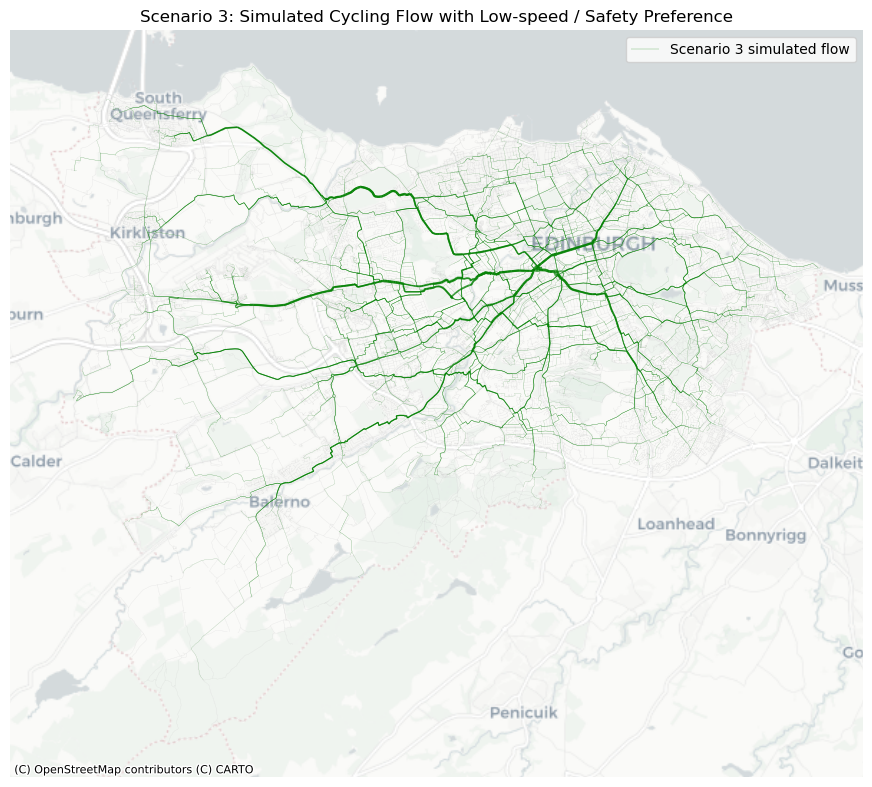

In [84]:
edges_sim3_3857 = edges_sim3.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(11, 11))

edges_sim3_3857.plot(
    ax=ax,
    linewidth=0.2,
    color="lightgrey",
    alpha=0.3
)

used_edges_low_speed = edges_sim3_3857[
    edges_sim3_3857["flow_low_speed"] > 0
].copy()

used_edges_low_speed.plot(
    ax=ax,
    linewidth=used_edges_low_speed["flow_low_speed"] / used_edges_low_speed["flow_low_speed"].max() * 4,
    color="green",
    alpha=0.8,
    label="Scenario 3 simulated flow"
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("Scenario 3: Simulated Cycling Flow with Low-speed / Safety Preference")
ax.set_axis_off()
ax.legend()

plt.show()

In [85]:
fig.savefig(FIG_DIR / "/Users/Guolijing/Desktop/ATUA/ATUA_Final_ABM_Cycling_Edinburgh/figures/scenario_3_low_speed_flow.png", dpi=300, bbox_inches="tight")


### Scenario 3 interpretation

Scenario 3 successfully routes all 500 agents. The overlay identifies 57,715 edges near 20mph roads, 13,615 near 30mph roads and 3,764 near higher-speed roads. The simulation uses 16,945 edges, slightly more than Scenario 1, with a maximum edge flow of 58 and a mean edge flow of about 0.763.

The green map pattern is less concentrated than Scenario 2 and extends across more of the street network. This suggests that low-speed/safety preference encourages more dispersed route choices across lower-speed streets.

# 7. Scenario comparison

The three scenarios are compared using the same 500 origin-destination pairs. This makes the comparison controlled: output differences are caused by route-cost assumptions, not different agents. The comparison uses summary statistics, flow concentration, preferred-route share and difference maps.

## 7.1 Summary comparison table


In [86]:
summary_compare = pd.DataFrame({
    "Scenario": [
        "Scenario 1: Shortest route",
        "Scenario 2: Quiet/Core path preference",
        "Scenario 3: Low-speed / safety preference"
    ],
    "Successful routes": [
        successful_routes,
        successful_routes_preferred,
        successful_routes_low_speed
    ],
    "Failed routes": [
        failed_routes,
        failed_routes_preferred,
        failed_routes_low_speed
    ],
    "Edges used (>0 flow)": [
        (edges_sim3["flow_shortest"] > 0).sum(),
        (edges_sim3["flow_preferred"] > 0).sum(),
        (edges_sim3["flow_low_speed"] > 0).sum()
    ],
    "Maximum edge flow": [
        edges_sim3["flow_shortest"].max(),
        edges_sim3["flow_preferred"].max(),
        edges_sim3["flow_low_speed"].max()
    ],
    "Mean edge flow": [
        round(edges_sim3["flow_shortest"].mean(), 3),
        round(edges_sim3["flow_preferred"].mean(), 3),
        round(edges_sim3["flow_low_speed"].mean(), 3)
    ]
})

summary_compare

,Scenario,Successful routes,Failed routes,Edges used (>0 flow),Maximum edge flow,Mean edge flow
0,Scenario 1: Shortest route,500,0,16731,52,0.710
1,Scenario 2: Quiet/Core path preference,500,0,13129,62,0.621
2,Scenario 3: Low-speed / safety preference,500,0,16945,58,0.763


### Summary table interpretation

All scenarios route 500 agents with no failed trips. Scenario 1 uses 16,731 edges and has a maximum edge flow of 52. Scenario 2 uses the fewest edges, 13,129, but has the highest maximum flow, 62. Scenario 3 uses the most edges, 16,945, with a maximum flow of 58. This suggests Scenario 2 is the most concentrated, while Scenario 3 is more distributed.

## 7.2 Flow concentration comparison

This metric calculates the share of total simulated flow carried by the top 5% of used edges. It helps measure whether a scenario spreads movement across the network or concentrates it on a small number of corridors.

In [87]:
def top_flow_share(edges, flow_col, q=0.95):
    used = edges[edges[flow_col] > 0].copy()
    threshold = used[flow_col].quantile(q)
    top_flow = used.loc[used[flow_col] >= threshold, flow_col].sum()
    total_flow = used[flow_col].sum()
    return top_flow / total_flow

concentration_compare = pd.DataFrame({
    "Scenario": [
        "Scenario 1: Shortest route",
        "Scenario 2: Quiet/Core path preference",
        "Scenario 3: Low-speed / safety preference"
    ],
    "Top 5% flow share": [
        round(top_flow_share(edges_sim3, "flow_shortest"), 3),
        round(top_flow_share(edges_sim3, "flow_preferred"), 3),
        round(top_flow_share(edges_sim3, "flow_low_speed"), 3)
    ]
})

concentration_compare

,Scenario,Top 5% flow share
0,Scenario 1: Shortest route,0.283
1,Scenario 2: Quiet/Core path preference,0.349
2,Scenario 3: Low-speed / safety preference,0.267


### Flow concentration interpretation

The top 5% of used edges carry 28.3% of total simulated flow in Scenario 1, 34.9% in Scenario 2 and 26.7% in Scenario 3. Scenario 2 therefore has the highest concentration, confirming that quiet/core path preference pulls agents onto selected cycling-friendly corridors. Scenario 3 has the lowest concentration, which supports the interpretation that low-speed preference spreads flow across a wider set of streets.

## 7.3 Preferred-route share comparison between Scenario 1 and Scenario 2


In [88]:
flow_shortest_on_preferred = edges_sim3.loc[
    edges_sim3["near_preferred_route"] == True, "flow_shortest"
].sum()

flow_preferred_on_preferred = edges_sim3.loc[
    edges_sim3["near_preferred_route"] == True, "flow_preferred"
].sum()

total_flow_shortest = edges_sim3["flow_shortest"].sum()
total_flow_preferred = edges_sim3["flow_preferred"].sum()

share_shortest_on_preferred = flow_shortest_on_preferred / total_flow_shortest
share_preferred_on_preferred = flow_preferred_on_preferred / total_flow_preferred

preferred_share_df = pd.DataFrame({
    "Scenario": ["Scenario 1: Shortest route", "Scenario 2: Quiet/Core path preference"],
    "Flow on preferred routes": [flow_shortest_on_preferred, flow_preferred_on_preferred],
    "Total flow": [total_flow_shortest, total_flow_preferred],
    "Share on preferred routes": [
        round(share_shortest_on_preferred, 3),
        round(share_preferred_on_preferred, 3)
    ]
})

preferred_share_df

,Scenario,Flow on preferred routes,Total flow,Share on preferred routes
0,Scenario 1: Shortest route,20114,61491,0.327
1,Scenario 2: Quiet/Core path preference,39198,53783,0.729


In [89]:
preferred_share_df = pd.DataFrame({
    "Scenario": ["Scenario 1", "Scenario 2"],
    "Flow on preferred routes": [flow_shortest_on_preferred, flow_preferred_on_preferred],
    "Total flow": [total_flow_shortest, total_flow_preferred],
    "Share on preferred routes": [share_shortest_on_preferred, share_preferred_on_preferred]
})

preferred_share_df

,Scenario,Flow on preferred routes,Total flow,Share on preferred routes
0,Scenario 1,20114,61491,0.327105
1,Scenario 2,39198,53783,0.728818


### Preferred-route share interpretation

This metric checks whether Scenario 2 shifts flow onto edges close to quiet routes and core paths. In Scenario 1, 32.7% of simulated flow occurs on preferred-route edges. In Scenario 2, this increases to 72.9%. The modified cost function therefore works as intended and redirects flow towards preferred infrastructure.

## 7.4 Difference map: Scenario 2 minus Scenario 1

In [90]:
edges_sim3["diff_preferred_shortest"] = (
    edges_sim3["flow_preferred"] - edges_sim3["flow_shortest"]
)

edges_compare_3857 = edges_sim3.to_crs(epsg=3857).copy()

edges_compare_3857["abs_diff_preferred"] = (
    edges_compare_3857["diff_preferred_shortest"].abs()
)

max_diff = edges_compare_3857["abs_diff_preferred"].max()

edges_compare_3857["plot_width_preferred"] = np.where(
    edges_compare_3857["abs_diff_preferred"] > 0,
    edges_compare_3857["abs_diff_preferred"] / max_diff * 4,
    0
)

edges_more_preferred = edges_compare_3857[
    edges_compare_3857["diff_preferred_shortest"] > 0
].copy()

edges_more_shortest = edges_compare_3857[
    edges_compare_3857["diff_preferred_shortest"] < 0
].copy()

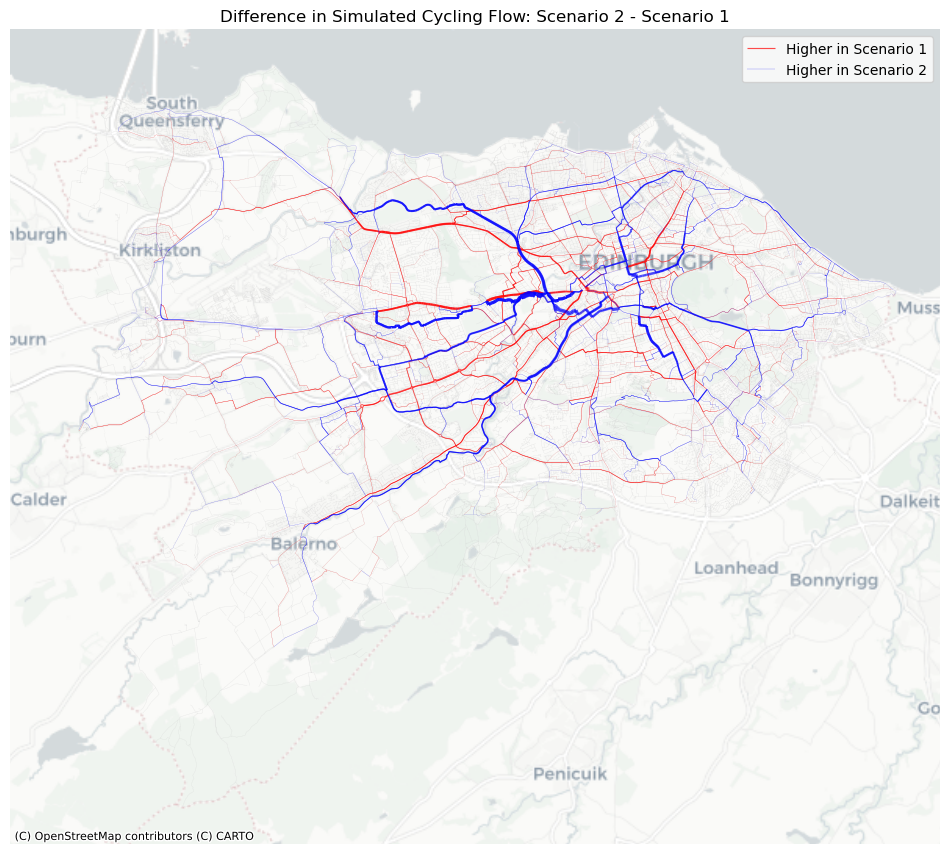

In [91]:
fig, ax = plt.subplots(figsize=(12, 12))

edges_compare_3857.plot(
    ax=ax,
    linewidth=0.2,
    color="lightgrey",
    alpha=0.3
)

edges_more_shortest.plot(
    ax=ax,
    linewidth=edges_more_shortest["plot_width_preferred"],
    color="red",
    alpha=0.7,
    label="Higher in Scenario 1"
)

edges_more_preferred.plot(
    ax=ax,
    linewidth=edges_more_preferred["plot_width_preferred"],
    color="blue",
    alpha=0.7,
    label="Higher in Scenario 2"
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("Difference in Simulated Cycling Flow: Scenario 2 - Scenario 1")
ax.set_axis_off()
ax.legend()

plt.show()

The difference map compares Scenario 2 with the shortest-route baseline. Blue lines show edges where simulated flow is higher in Scenario 2, while red lines show edges where flow is higher in Scenario 1. The map shows that quiet/core path preference redirects some simulated cyclists away from the shortest direct routes and towards selected cycling-friendly corridors. The strongest blue segments indicate where the preferred-route cost function has the greatest effect. This confirms that Scenario 2 does not simply reproduce the shortest-path pattern, but changes the spatial distribution of flow by attracting agents towards quiet routes and core paths.


## 7.5 Difference map: Scenario 3 minus Scenario 1

In [92]:
edges_sim3["diff_low_speed_shortest"] = (
    edges_sim3["flow_low_speed"] - edges_sim3["flow_shortest"]
)

edges_compare_3857 = edges_sim3.to_crs(epsg=3857).copy()

edges_compare_3857["abs_diff_low_speed"] = (
    edges_compare_3857["diff_low_speed_shortest"].abs()
)

max_diff = edges_compare_3857["abs_diff_low_speed"].max()

edges_compare_3857["plot_width_low_speed"] = np.where(
    edges_compare_3857["abs_diff_low_speed"] > 0,
    edges_compare_3857["abs_diff_low_speed"] / max_diff * 4,
    0
)

edges_more_low_speed = edges_compare_3857[
    edges_compare_3857["diff_low_speed_shortest"] > 0
].copy()

edges_more_shortest_3 = edges_compare_3857[
    edges_compare_3857["diff_low_speed_shortest"] < 0
].copy()

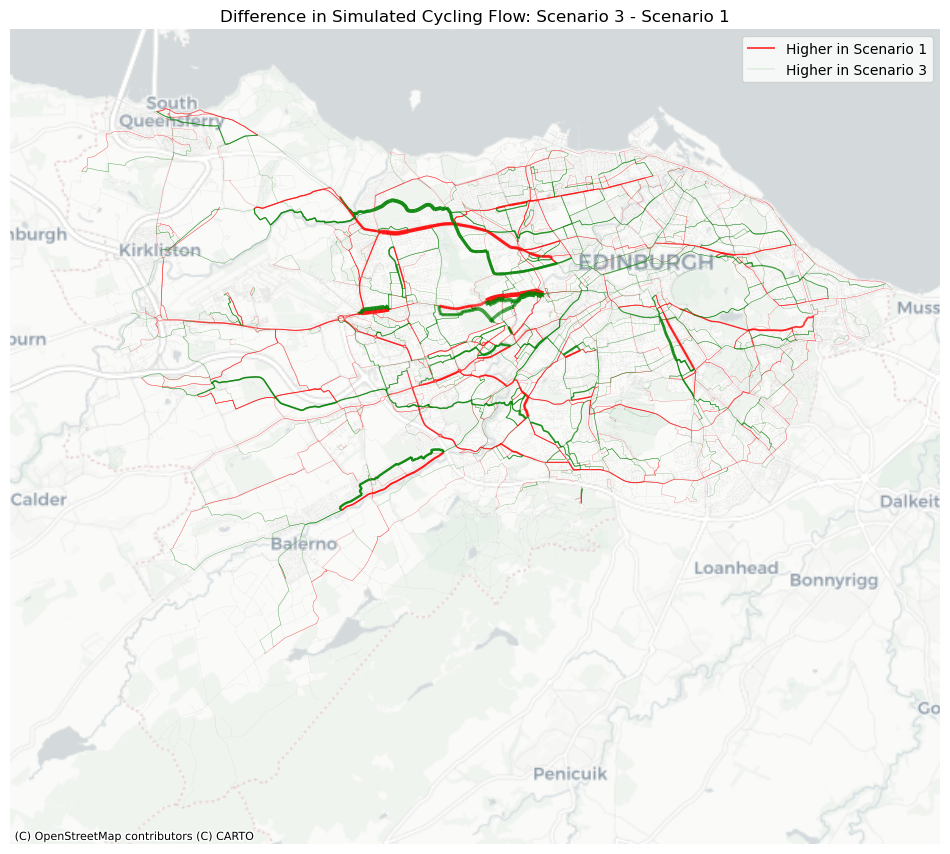

In [93]:
fig, ax = plt.subplots(figsize=(12, 12))

edges_compare_3857.plot(
    ax=ax,
    linewidth=0.2,
    color="lightgrey",
    alpha=0.3
)

edges_more_shortest_3.plot(
    ax=ax,
    linewidth=edges_more_shortest_3["plot_width_low_speed"],
    color="red",
    alpha=0.7,
    label="Higher in Scenario 1"
)

edges_more_low_speed.plot(
    ax=ax,
    linewidth=edges_more_low_speed["plot_width_low_speed"],
    color="green",
    alpha=0.7,
    label="Higher in Scenario 3"
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("Difference in Simulated Cycling Flow: Scenario 3 - Scenario 1")
ax.set_axis_off()
ax.legend()

plt.show()

The Scenario 3 difference map compares the low-speed/safety preference scenario with the shortest-route baseline. Green lines show edges where simulated flow is higher in Scenario 3, while red lines show edges where Scenario 1 has higher flow. The map suggests that low-speed preference shifts some agents away from direct shortest routes and towards lower-speed streets. Compared with Scenario 2, the green pattern appears more dispersed rather than strongly concentrated on a few corridors. This supports the statistical results, where Scenario 3 uses more edges and produces a wider distribution of simulated cycling flow.


# 8. Rough validation using observed cycling counter data

Validation uses observed cycling counters as a rough spatial check. It focuses on Scenario 2 because this scenario directly models preference for cycling-friendly infrastructure, and cycling planning tools often compare modelled flow corridors with observed or potential demand (Lovelace et al., 2017).

This is not a precise prediction test. The ABM uses random origin-destination pairs, while real cycling flows are shaped by commuting demand, residential density, employment locations, schools, universities, topography, weather and counter placement. The validation therefore asks whether simulated high-flow corridors are close to observed high-count counters.

## 8.1 Identify Scenario 2 high-flow edges


In [94]:
# Use Scenario 2 as the main validation target
used_edges_preferred = edges_sim3[edges_sim3["flow_preferred"] > 0].copy()

# Select top 5% of used edges by Scenario 2 simulated flow
high_flow_threshold = used_edges_preferred["flow_preferred"].quantile(0.95)

high_flow_edges = used_edges_preferred[
    used_edges_preferred["flow_preferred"] >= high_flow_threshold
].copy()

print("High-flow threshold:", high_flow_threshold)
print("High-flow edges:", high_flow_edges.shape)

High-flow threshold: 20.0
High-flow edges: (662, 30)


## 8.2 Identify observed high-count cycling counters


In [95]:
# Select top 25% observed counters by mean daily cycling count
high_counter_threshold = counter_gdf["mean_daily_cycle_count"].quantile(0.75)

high_count_counters = counter_gdf[
    counter_gdf["mean_daily_cycle_count"] >= high_counter_threshold
].copy()

print("High-count counter threshold:", high_counter_threshold)
print("High-count counters:", high_count_counters.shape)

high_count_counters[["siteID", "location", "mean_daily_cycle_count"]].sort_values(
    "mean_daily_cycle_count",
    ascending=False
)

High-count counter threshold: 355.7067988668555
High-count counters: (7, 6)


,siteID,location,mean_daily_cycle_count
3,EDH0022,"North Meadow Walk, Main Path",1060.096317
13,EDH0032,Inverleith Row,795.500000
15,EDH0034,Nicolson Street,496.730878
18,EDH0037,Whitehouse Loan,482.198300
16,EDH0035,A90 Deans Bridge,412.620397
30,EDH0049,Carrington Road Eastbound,401.991379
8,EDH0027,Harrison Park,400.861190


## 8.3 Spatial matching with 100m and 200m buffers


In [96]:
# Convert to British National Grid for distance-based validation
high_flow_edges_27700 = high_flow_edges.to_crs(epsg=27700)
high_count_counters_27700 = high_count_counters.to_crs(epsg=27700)

# 100m buffer around simulated high-flow edges
high_flow_buffer_100m = high_flow_edges_27700.buffer(100).union_all()

high_count_counters_27700["near_simulated_high_flow_100m"] = (
    high_count_counters_27700.geometry.within(high_flow_buffer_100m)
)

print(high_count_counters_27700["near_simulated_high_flow_100m"].value_counts())

validation_ratio_100m = high_count_counters_27700[
    "near_simulated_high_flow_100m"
].mean()

print("100m validation ratio:", validation_ratio_100m)

near_simulated_high_flow_100m
False    5
True     2
Name: count, dtype: int64
100m validation ratio: 0.2857142857142857


In [97]:
# 200m buffer sensitivity check
high_flow_buffer_200m = high_flow_edges_27700.buffer(200).union_all()

high_count_counters_27700["near_simulated_high_flow_200m"] = (
    high_count_counters_27700.geometry.within(high_flow_buffer_200m)
)

print(high_count_counters_27700["near_simulated_high_flow_200m"].value_counts())

validation_ratio_200m = high_count_counters_27700[
    "near_simulated_high_flow_200m"
].mean()

print("200m validation ratio:", validation_ratio_200m)

near_simulated_high_flow_200m
False    4
True     3
Name: count, dtype: int64
200m validation ratio: 0.42857142857142855


## 8.4 Validation summary table


In [98]:
validation_summary = pd.DataFrame({
    "Buffer distance": ["100m", "200m"],
    "Matched high-count counters": [
        high_count_counters_27700["near_simulated_high_flow_100m"].sum(),
        high_count_counters_27700["near_simulated_high_flow_200m"].sum()
    ],
    "Total high-count counters": [
        len(high_count_counters_27700),
        len(high_count_counters_27700)
    ],
    "Validation ratio": [
        round(validation_ratio_100m, 3),
        round(validation_ratio_200m, 3)
    ]
})

validation_summary

,Buffer distance,Matched high-count counters,Total high-count counters,Validation ratio
0,100m,2,7,0.286
1,200m,3,7,0.429


## 8.5 Validation map


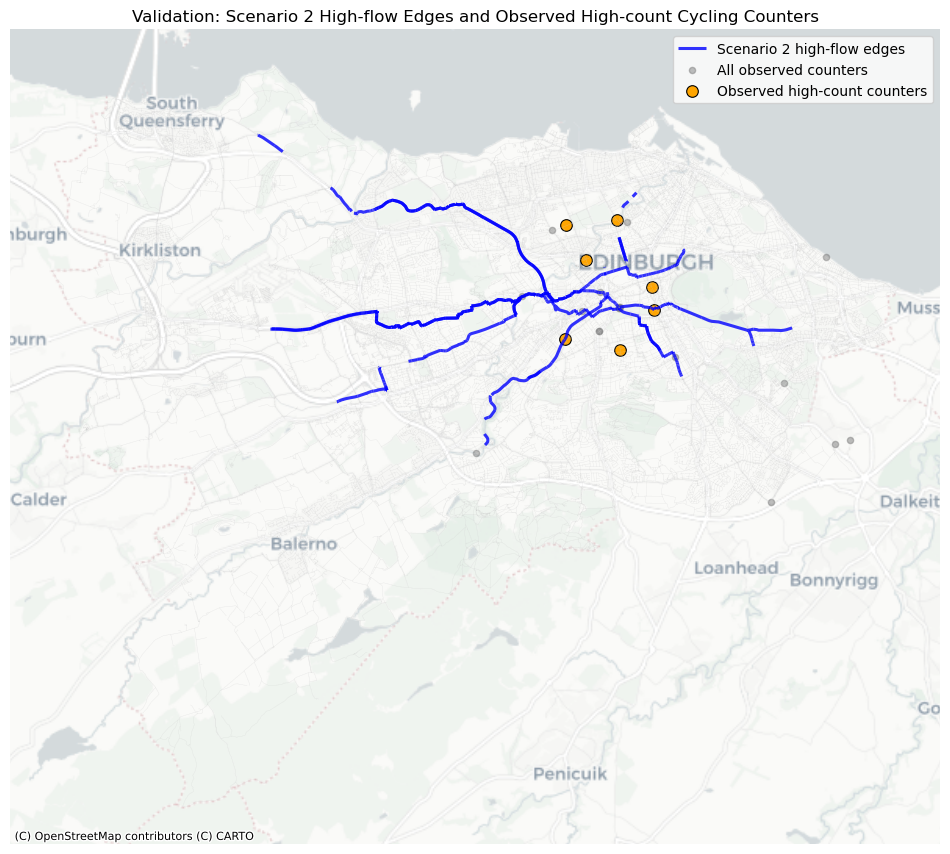

In [99]:
high_flow_edges_3857 = high_flow_edges.to_crs(epsg=3857)
counter_gdf_3857 = counter_gdf.to_crs(epsg=3857)
high_count_counters_3857 = high_count_counters.to_crs(epsg=3857)
edges_sim3_3857 = edges_sim3.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))

# Background network
edges_sim3_3857.plot(
    ax=ax,
    linewidth=0.2,
    color="lightgrey",
    alpha=0.3
)

# Simulated high-flow edges from Scenario 2
high_flow_edges_3857.plot(
    ax=ax,
    linewidth=2.2,
    color="blue",
    alpha=0.8,
    label="Scenario 2 high-flow edges"
)

# All observed counters
counter_gdf_3857.plot(
    ax=ax,
    markersize=20,
    color="grey",
    alpha=0.5,
    label="All observed counters"
)

# Observed high-count counters
high_count_counters_3857.plot(
    ax=ax,
    markersize=70,
    color="orange",
    edgecolor="black",
    linewidth=0.8,
    label="Observed high-count counters"
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("Validation: Scenario 2 High-flow Edges and Observed High-count Cycling Counters")
ax.set_axis_off()
ax.legend()

plt.show()

In [ ]:
fig.savefig("/Users/Guolijing/Desktop/ATUA/ATUA_Final_ABM_Cycling_Edinburgh/figures/validation_scenario2_high_flow_counters.png", dpi=300, bbox_inches="tight")


## 8.6 Validation interpretation

High-flow simulated edges are defined as the top 5% of used edges in Scenario 2, producing 662 high-flow edges with a threshold of 20 agents. Observed high-count counters are defined as the top 25% of counters by mean daily count, producing seven high-count counters.

Using a 100m buffer, 2 out of 7 high-count counters are near simulated high-flow corridors, giving a validation ratio of 28.6%. With a 200m buffer, 3 out of 7 counters are matched, increasing the ratio to 42.9%. The validation map shows blue simulated high-flow edges, grey counter locations and orange high-count counters.

These results show partial agreement. The model captures some broad areas of observed cycling activity, but it does not fully reproduce real cycling flows. This is expected because the model uses random origins and destinations rather than observed travel demand.

## 9. Discussion and conclusion

The main research question asked how different route-choice preferences change simulated cycling flows in Edinburgh. The results show that cycling flow patterns are sensitive to behavioural assumptions. When agents only minimise distance, the model produces a baseline pattern based on network efficiency. However, when comfort or safety assumptions are added, the simulated flow distribution changes clearly.

The first sub-question is answered by Scenario 1: shortest-route preference creates direct movement corridors, but does not fully explain cycling-friendly route use. The second sub-question is answered by Scenario 2: quiet/core path preference strongly shifts flow towards preferred cycling infrastructure. This is shown by the increase in flow on preferred routes from 32.7% to 72.9%, suggesting that infrastructure preference can substantially reshape simulated route choice. The third sub-question is answered by Scenario 3: low-speed/safety preference produces a more dispersed pattern rather than concentrating flow on a few corridors. This suggests that safety-oriented cycling behaviour may support a wider network of lower-speed streets.

The fourth sub-question considered validation. The comparison with observed counters shows only partial alignment, with 28.6% of high-count counters matched within 100m and 42.9% within 200m. This means the model captures some broad spatial patterns, but it should not be treated as a precise prediction of real cycling demand.

Overall, the project demonstrates that ABM is useful for testing how different assumptions about cyclist behaviour may affect urban cycling flows. The main limitation is that origins and destinations are randomly generated, so future work should use more realistic demand data, such as population, employment, schools, universities or commuting flows. Additional factors such as slope, junction safety and traffic stress could also improve the behavioural realism of the model.


# References

Boeing, G. (2017) ‘OSMnx: New methods for acquiring, constructing, analyzing, and visualizing complex street networks’, *Computers, Environment and Urban Systems*, 65, pp. 126–139. Available at: https://doi.org/10.1016/j.compenvurbsys.2017.05.004

Broach, J., Dill, J. and Gliebe, J. (2012) ‘Where do cyclists ride? A route choice model developed with revealed preference GPS data’, *Transportation Research Part A: Policy and Practice*, 46(10), pp. 1730–1740. Available at: https://doi.org/10.1016/j.tra.2012.07.005

City of Edinburgh Council (n.d.) ‘Walking and cycling statistics’. Available at: https://www.edinburgh.gov.uk/cycling-walking/statistics-cycling-edinburgh

Crooks, A.T. and Heppenstall, A.J. (2012) ‘Introduction to agent-based modelling’, in A.J. Heppenstall, A.T. Crooks, L.M. See and M. Batty (eds.) *Agent-Based Models of Geographical Systems*. Dordrecht: Springer, pp. 85–105. Available at: https://doi.org/10.1007/978-90-481-8927-4

Hood, J., Sall, E. and Charlton, B. (2011) ‘A GPS-based bicycle route choice model for San Francisco, California’, *Transportation Letters*, 3(1), pp. 63–75. Available at: https://doi.org/10.3328/TL.2011.03.01.63-75

Lovelace, R., Goodman, A., Aldred, R., Berkoff, N., Abbas, A. and Woodcock, J. (2017) ‘The Propensity to Cycle Tool: An open source online system for sustainable transport planning’, *Journal of Transport and Land Use*, 10(1), pp. 505–528. Available at: https://doi.org/10.5198/jtlu.2016.862